# Entrenamiento de modelos

2026-02-04 12:50:45.548887: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 12:50:45.549488: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-04 12:50:45.552604: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-04 12:50:45.565729: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770220245.581747  456238 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770220245.58

Usando mnist como dataset


2026-02-04 12:50:48.063542: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/3
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - kl_loss: 3.8625 - loss: 54.0566 - reconstruction_loss: 50.2022 - val_kl_loss: 1.7070 - val_loss: 38.8884 - val_reconstruction_loss: 37.2671
Epoch 2/3
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 2.0845 - loss: 38.0849 - reconstruction_loss: 35.9995 - val_kl_loss: 2.2604 - val_loss: 35.8186 - val_reconstruction_loss: 33.5582
Epoch 3/3
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 2.4626 - loss: 36.0072 - reconstruction_loss: 33.5434 - val_kl_loss: 2.5161 - val_loss: 34.3794 - val_reconstruction_loss: 31.8828


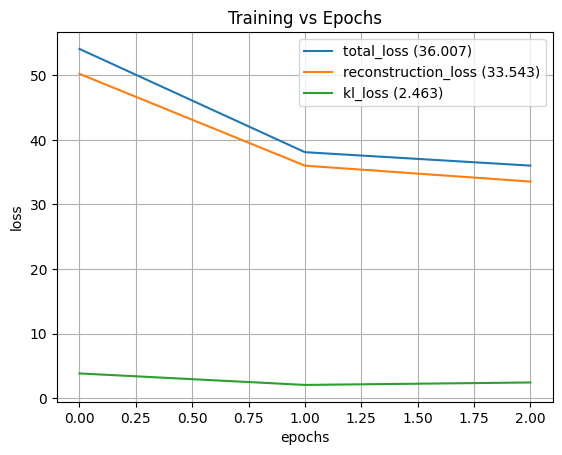

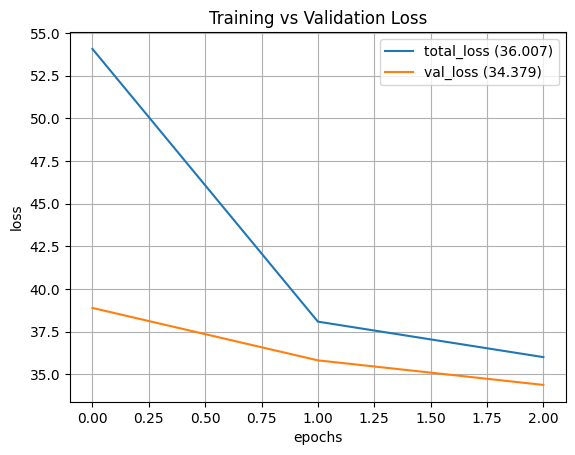

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader
from project.models_definitions import Encoder, Decoder, CVAE
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping

#Constantes
BATCH_SIZE = 128
ORIGINAL_DIM = 784
DATASET = "mnist"
BETA = 1.0
EPOCHS= 3

MODEL_TO_TRAIN = [
    {"inter": 128, "lat": 2},
#    {"inter": 128, "lat": 64},
#    {"inter": 256, "lat": 64},
#    {"inter": 256, "lat": 128},
#    {"inter": 512, "lat": 128},
#    {"inter": 512, "lat": 256},
#    {"inter": 784, "lat": 784},
]


## parametros
data = Loader.data(dataset=DATASET)

x_train = data["x_train"]
y_train = data["y_train"]

x_val = data["x_val"]
y_val = data["y_val"]


train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(BATCH_SIZE)

intermediate_dim = [128,128,256,256,512,512,784]
latent_dim =      [2,64,64,128,128,256,784]

for model in MODEL_TO_TRAIN:
    
    inter = model["inter"]
    lat = model["lat"]

    en = Encoder(
        intermediate_dim=inter,
        latent_dim=lat,
    )
    de = Decoder(
        intermediate_dim=inter,
        latent_dim=lat,
    )
    cvae_model = CVAE(
        encoder=en,
        decoder=de,
        original_dim=ORIGINAL_DIM,
        beta=BETA,
        name=f"cvae_int_{inter}_lat_{lat}_gamma_2",
    )

    optimizer = tf.keras.optimizers.Adam()
    cvae_model.compile(optimizer=optimizer)


    cvae_model.total_loss_tracker.reset_state()
    cvae_model.reconstruction_loss_tracker.reset_state()
    cvae_model.kl_loss_tracker.reset_state()

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = cvae_model.fit(
        train_dataset,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=val_dataset,
        callbacks=[early_stopping],
        verbose=1
    )

    #en.save(f"en_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")
    #de.save(f"de_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras")

    loss_val = round(history.history["loss"][-1], 3)
    recon_val = round(history.history["reconstruction_loss"][-1], 3)
    kl_val = round(history.history["kl_loss"][-1], 3)
    
    plt.plot(history.history["loss"], label=f"total_loss ({loss_val})")
    plt.plot(history.history["reconstruction_loss"], label=f"reconstruction_loss ({recon_val})")
    plt.plot(history.history["kl_loss"], label=f"kl_loss ({kl_val})")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.title("Training vs Epochs")
    plt.legend()
    #plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
    plt.show()
    loss_val = round(history.history["loss"][-1], 3)
    val_loss_val = round(history.history["val_loss"][-1], 3)
    
    plt.plot(history.history["loss"], label=f"total_loss ({loss_val})")
    plt.plot(history.history["val_loss"], label=f"val_loss ({val_loss_val})")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.title("Training vs Validation Loss")
    plt.legend()
    #plt.savefig(f"training_loss_vs_val_loss_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
    plt.show()


Usando mnist como dataset
Epoch 1/3
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.3189 - val_loss: 0.1966
Epoch 2/3
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1119 - val_loss: 0.0758
Epoch 3/3
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0842 - val_loss: 0.0543


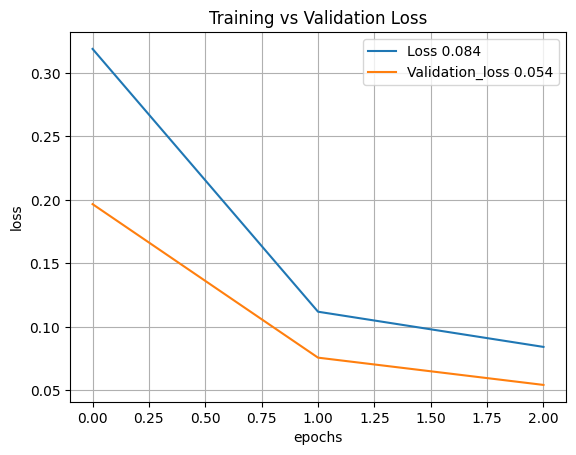

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader
from project.models_definitions import Predictor
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping

#Constantes
BATCH_SIZE = 128
DATASET = "mnist"
BETA = 1.0
EPOCHS= 3

## parametros
data = Loader.data(dataset=DATASET)

x_train = data["x_train"]
y_train = data["y_train"]

x_val = data["x_val"]
y_val = data["y_val"]


train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(BATCH_SIZE)

predictor = Predictor()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

predictor.compile(optimizer, loss="categorical_crossentropy")


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = predictor.fit(
    x=x_train,
    y=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1)

loss = round(history.history["loss"][-1], 3)
loss_val = round(history.history["val_loss"][-1], 3)

#predictor.save("early_stop_fashion.keras")
plt.plot(history.history["loss"], label=f"Loss {loss}" )
plt.plot(history.history["val_loss"], label=f"Validation_loss {loss_val}" )
plt.title("Training vs Validation Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.grid()
plt.legend()
#plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
plt.show()

# Carga de modelos

In [3]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader
from project.models_definitions import Encoder, Decoder, CVAE
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping


DATASET="mnist"
lat=2
inter=128

#Cargar un solo auto-enconder
cvae_model = Loader.cvae(lat=lat,inter=inter,dataset=DATASET)


#Cargar todos los CVAE disponibles
models = Loader.all_cvaes(dataset=DATASET)

#cargar un predictor
predictor = Loader.predictor(dataset=DATASET)




# Pruebas de CVAE

## Espacio latente

Usando mnist como dataset


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


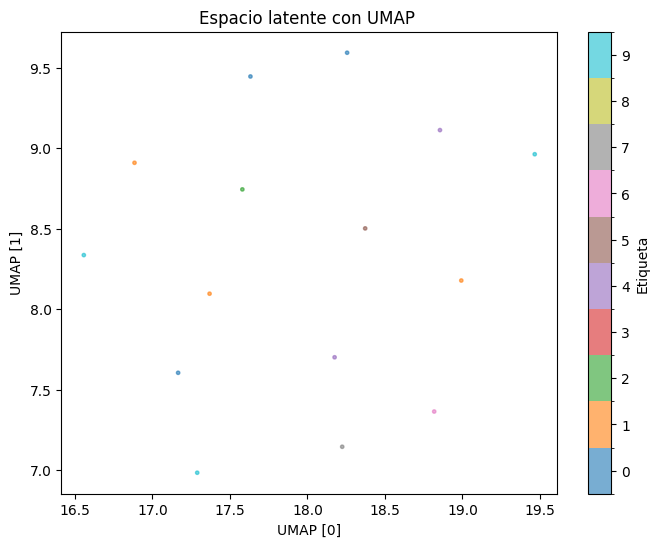

In [4]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader

import project.visualizations.visualizations as vis
import tensorflow as tf

DATASET="mnist"

cvae = Loader.cvae(lat=64, inter=128, dataset=DATASET)

data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)


x_test = data["x_test"]
y_test = data["y_test"]
labels = data["labels"]

test_dataset = tf.data.Dataset.from_tensor_slices(((x_test, y_test), x_test))


vis.latent_space_umap(cvae, test_dataset, max_samples=15,label_names=labels, title= cvae.name)





## Error de reconstrucción

Usando mnist como dataset
cvae_int_128_lat_64
cvae_int_256_lat_64
cvae_int_512_lat_256
cvae_int_128_lat_2
cvae_int_784_lat_784
cvae_int_512_lat_128
cvae_int_256_lat_128


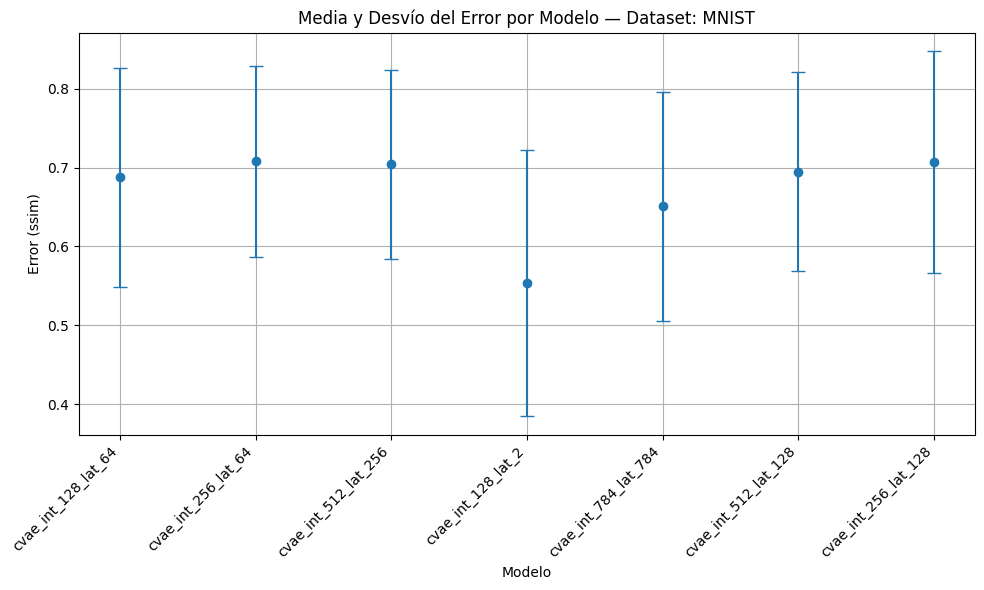

In [5]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader
from project.metrics.metrics import Metrics 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

DATASET = "mnist"
METRIC = "ssim" 
N_PICTURES = 100
N_PIXELS=28

data = Loader.data(dataset=DATASET)

models = Loader.all_cvaes(dataset=DATASET)

x_test = data["x_test"]
y_test = data["y_test"]

resultados = []
errores = []  

for m in models:

    print(m.name)

    errores_modelo = []  

    for i in range(N_PICTURES):
        x = x_test[i : i + 1]  # (1, 28, 28)
        y = y_test[i: i + 1]  # (1, 10)

        # Codificar
        z_mean, _, z = m.encoder.predict([x, y], verbose=0)

        # Decodificar
        x_recon = m.decoder.predict([z, y], verbose=0)

        # Calcular error
        if METRIC == "psnr":
             error_value = Metrics.psnr_grayscale(target=x, preds=x_recon)
        else:
            error_value = Metrics.ssim_grayscale(target=x, preds=x_recon)   
           
        errores_modelo.append(error_value)

    errores.append(errores_modelo)
    
    x_pic = tf.reshape(x, (N_PIXELS, N_PIXELS))
    x_recon = tf.reshape(x_recon, (N_PIXELS, N_PIXELS))

errores_np = np.array(errores)

means = errores_np.mean(axis=1).ravel()
stds  = errores_np.std(axis=1).ravel()

# Obtener nombres de modelos sin el sufijo del dataset
model_names = [m.name.replace(f"_{DATASET}.keras", "") for m in models]

x = np.arange(len(means))

plt.figure(figsize=(10, 6))
plt.errorbar(x, means, yerr=stds, fmt='o', capsize=5)

plt.title(f"Media y Desvío del Error por Modelo — Dataset: {DATASET.upper()}")
plt.xlabel("Modelo")
plt.ylabel(f"Error ({METRIC})")
plt.grid(True)

# Usar nombres como ticks
plt.xticks(x, model_names, rotation=45, ha="right")

plt.tight_layout()
plt.show()




## Reconstrución de un imagen para cada modelo 

Usando mnist como dataset


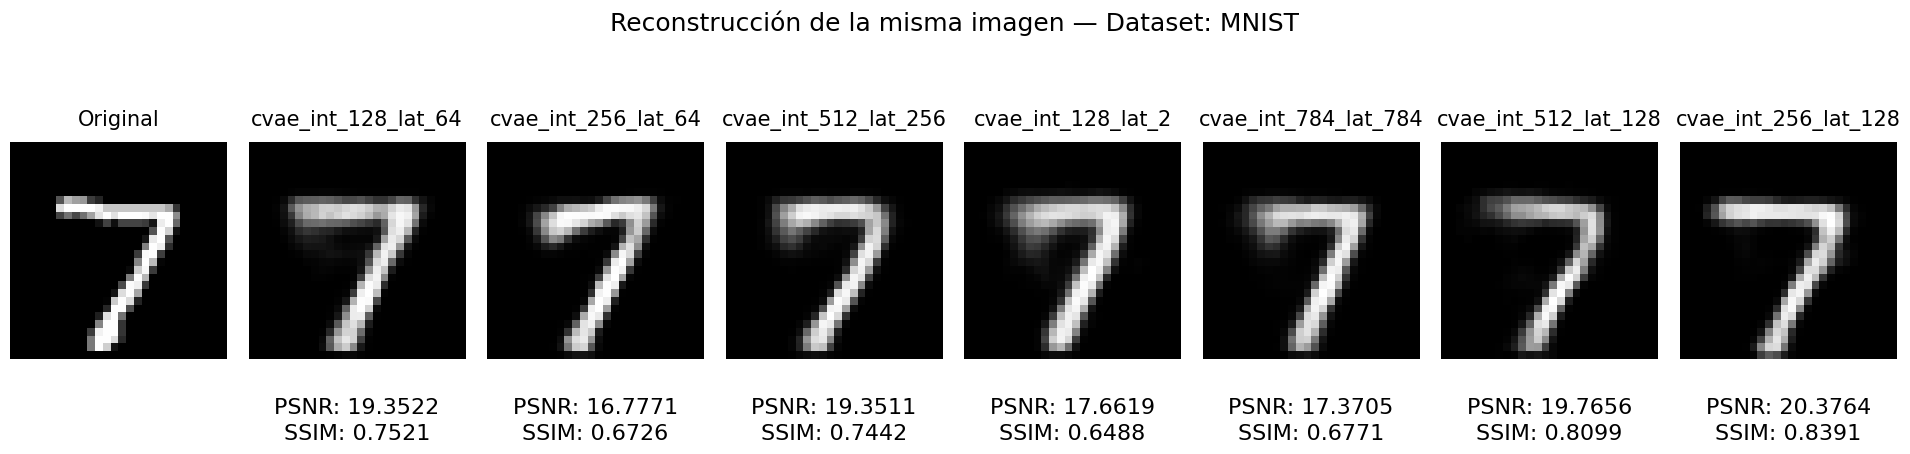

In [6]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader
from project.metrics.metrics import Metrics 
import matplotlib.pyplot as plt

DATASET = "mnist"
data = Loader.data(dataset=DATASET)
models = Loader.all_cvaes(dataset=DATASET)
IDX_IMG = 0

x_test = data["x_test"]
y_test = data["y_test"]

# -------- Configuración --------
x = x_test[IDX_IMG:IDX_IMG+1]   # (1, 28, 28)
y = y_test[IDX_IMG: IDX_IMG+1]   # (1, 10)

n_models = len(models)

# -------- Crear figura --------
fig, axes = plt.subplots(1, len(models) + 1,
                         figsize=(2.6*len(models)+1, 4.8))
plt.subplots_adjust(top=0.75)

# Imagen original
axes[0].imshow(x.reshape(28, 28), cmap="gray")
axes[0].set_title("Original", pad=12, fontsize=15)
axes[0].axis("off")

for i, m in enumerate(models):

    z_mean, _, z = m.encoder.predict([x, y], verbose=0)
    x_recon = m.decoder.predict([z, y], verbose=0)

    # -------- Calcular métricas --------
    psnr_value = float(
        Metrics.psnr_grayscale(target=x, preds=x_recon)
    )
    ssim_value = float(
        Metrics.ssim_grayscale(target=x, preds=x_recon)
    )

    ax = axes[i + 1]
    ax.imshow(x_recon.reshape(28, 28), cmap="gray")

    model_name = m.name.replace(f"_{DATASET}.keras", "")

    # Nombre del modelo arriba
    ax.set_title(model_name, pad=12, fontsize=15)

    # -------- Métricas abajo --------
    ax.text(
        0.5, -0.18,
        f"PSNR: {psnr_value:.4f}",
        ha="center",
        va="top",
        transform=ax.transAxes,
        fontsize=16
    )

    ax.text(
        0.5, -0.30,
        f"SSIM: {ssim_value:.4f}",
        ha="center",
        va="top",
        transform=ax.transAxes,
        fontsize=16
    )

    ax.axis("off")

plt.suptitle(
    f"Reconstrucción de la misma imagen — Dataset: {DATASET.upper()}",
    fontsize=18,
    y=0.95
)

plt.tight_layout(rect=[0, 0.08, 1, 0.9])
plt.show()


## Error de reconstrucción por clase

Usando fashion como dataset


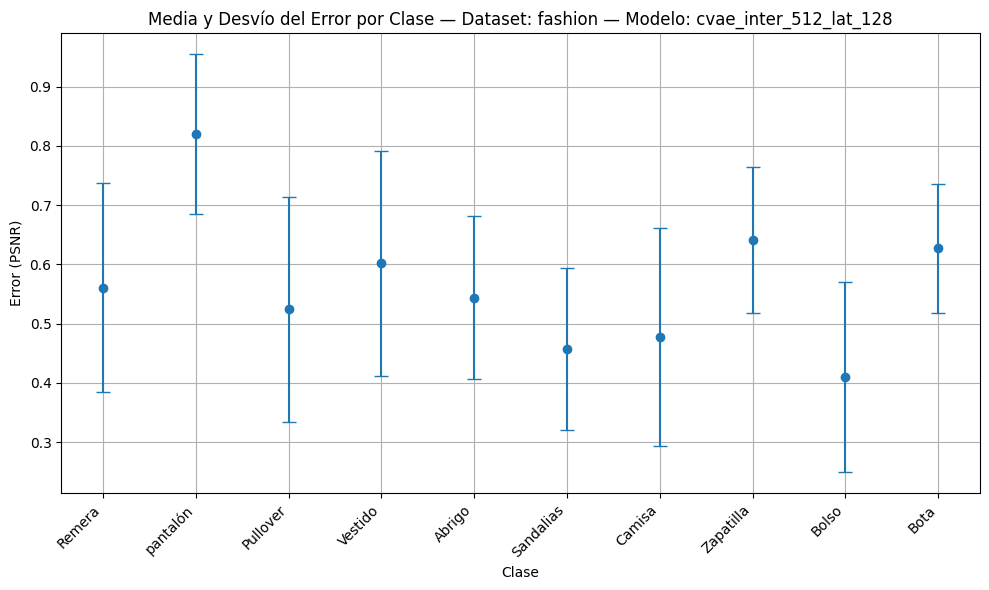

In [7]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader
from project.metrics.metrics import Metrics 
import numpy as np
import matplotlib.pyplot as plt

DATASET = "fashion"
N_PICTURES = 1000

def estadisticas_por_clase(errores_modelo, num_clases=10):
    # errores_modelo = [(clase, error), ...]
    
    agrupados = {c: [] for c in range(num_clases)}
    for c, e in errores_modelo:
        agrupados[c].append(e)
    
    means = np.array([np.mean(agrupados[c]) for c in range(num_clases)])
    stds  = np.array([np.std(agrupados[c]) for c in range(num_clases)])
    return means, stds



data = Loader.data(dataset=DATASET)

model = Loader.cvae(inter=256,lat=64,dataset=DATASET)

x_test = data["x_test"]
y_test = data["y_test"]
labels = data["labels"]
resultados = []
errores = [] 

errores_modelo = []  

for idx in range(N_PICTURES):
    x = x_test[idx : idx + 1]
    y = y_test[idx : idx + 1]

    # Codificar
    z_mean, _, z = model.encoder.predict([x, y], verbose=0)

    # Decodificar
    x_recon = model.decoder.predict([z, y], verbose=0)

    # Calcular clase y error
    clase = int(np.argmax(y))
    error_value = Metrics.ssim_grayscale(target=x, preds=x_recon)

    errores_modelo.append((clase, error_value))

errores.append(errores_modelo)


modelo_idx = 0   # elegí el modelo que quieras graficar
errores_modelo = errores[modelo_idx]

means, stds = estadisticas_por_clase(errores_modelo)

clases = np.arange(len(means))


plt.figure(figsize=(10, 6))
plt.errorbar(clases, means, yerr=stds, fmt='o', capsize=5)

plt.title(f"Media y Desvío del Error por Clase — Dataset: {DATASET} — Modelo: cvae_inter_512_lat_128")
plt.xlabel("Clase")
plt.ylabel("Error (PSNR)")
plt.grid(True)

plt.xticks(clases, labels, rotation=45, ha="right")
plt.tight_layout()
#plt.savefig("ssim_reconstruccion_por_clase_mnist_inter_512_lat_128")
plt.show()


# CROP 

## Curvas de acc

Usando fashion como dataset


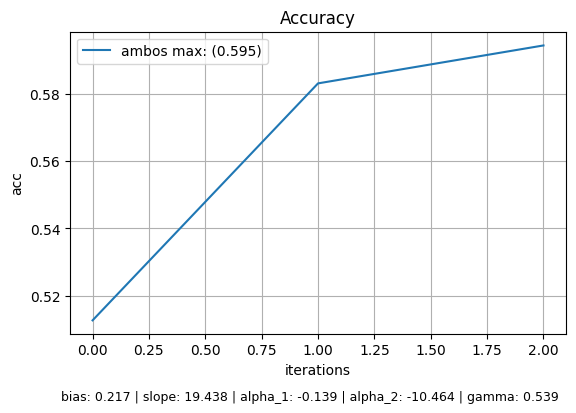

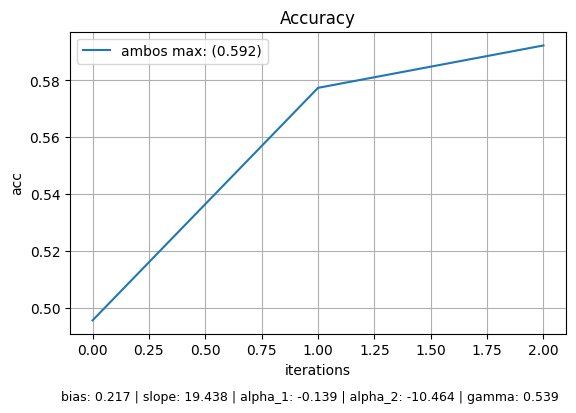

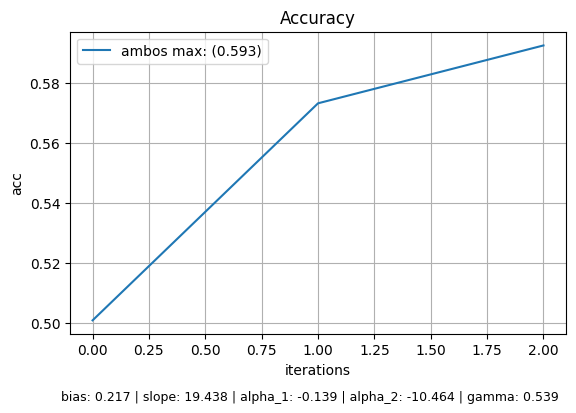

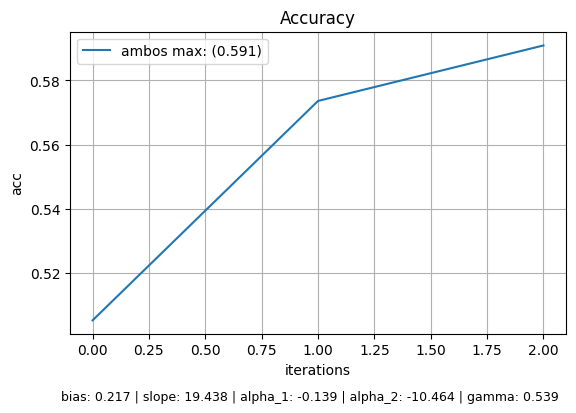

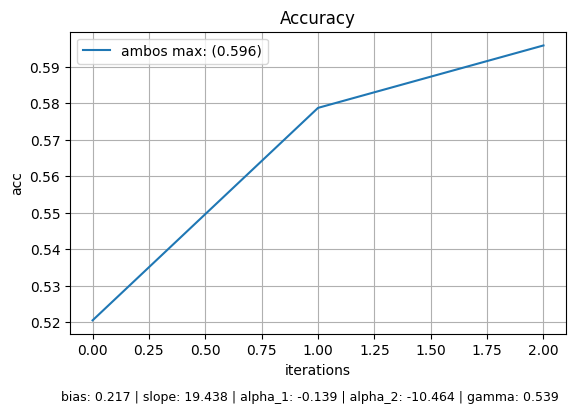

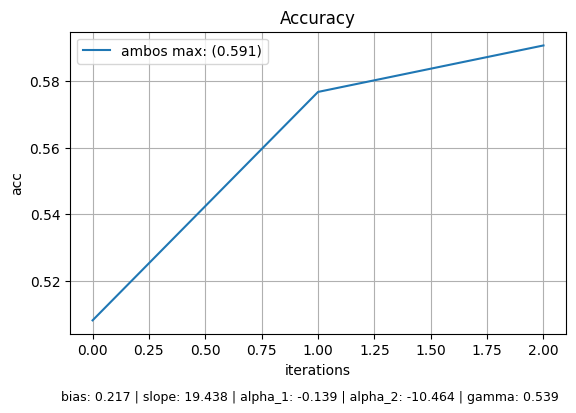

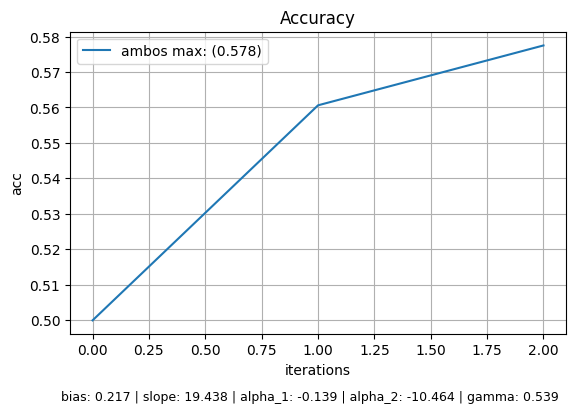

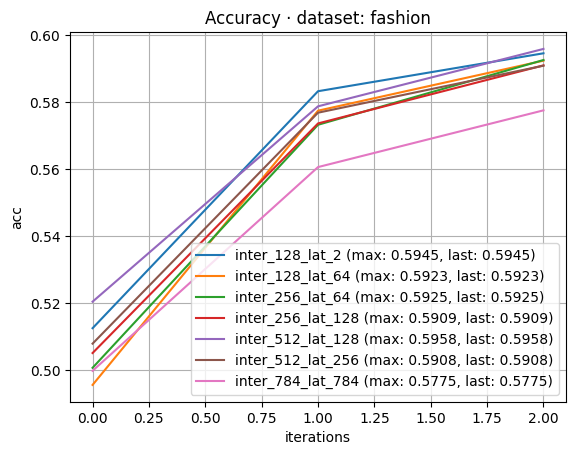

In [8]:
#codigo de curvas
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader
from project.CROP.models.crop2 import Crop2


# -------------------- config --------------------
DATASET = "fashion"
ITERATIONS = 3

MNIST_PARAMS = {
    'bias': 0.21716868437244724,
    'slope': 19.437646607877017,
    'alpha_1': -0.13863158439804657,
    'alpha_2': -10.463749682840565,
    'gamma': 0.5392507616026618
}

MODELS = [
    {"inter": 128, "lat": 2},
    {"inter": 128, "lat": 64},
    {"inter": 256, "lat": 64},
   {"inter": 256, "lat": 128},
   {"inter": 512, "lat": 128},
   {"inter": 512, "lat": 256},
   {"inter": 784, "lat": 784},
]


# -------------------- data & predictor --------------------
data = Loader.data(dataset=DATASET)
predictor = Loader.predictor(dataset=DATASET)

x_test, x_test_1 = data["x_test"], data["x_test_1"]
y_test, y_test_1 = data["y_test"], data["y_test_1"]


# -------------------- evaluation --------------------
results = {}

for model in MODELS:
    
    inter = model["inter"]
    lat = model["lat"]
    
    #cvae = Loader.cvae(lat=lat, inter=inter, dataset=DATASET)
    crop = Crop2(predictor=predictor, lat=lat,inter=inter,dataset=DATASET)

    metrics = crop.acc_curve(
        x_test,
        x_test_1,
        y_test,
        y_test_1,
        iterations=ITERATIONS,
        params=MNIST_PARAMS
    )

    results[(lat, inter)] = metrics


# -------------------- plot --------------------
for (lat, inter), m in results.items():
    acc = m["acc_both_plot"]
    plt.plot(
        acc,
        label=f"inter_{inter}_lat_{lat} "
              f"(max: {np.max(acc):.4f}, last: {acc[-1]:.4f})"
    )

plt.grid()
plt.title(f"Accuracy · dataset: {DATASET}")
plt.xlabel("iterations")
plt.ylabel("acc")
plt.legend()
#plt.savefig(f"acc_both_more_models_{DATASET}_________.png")
plt.show()


## Sepración de dígitos

Usando mnist como dataset


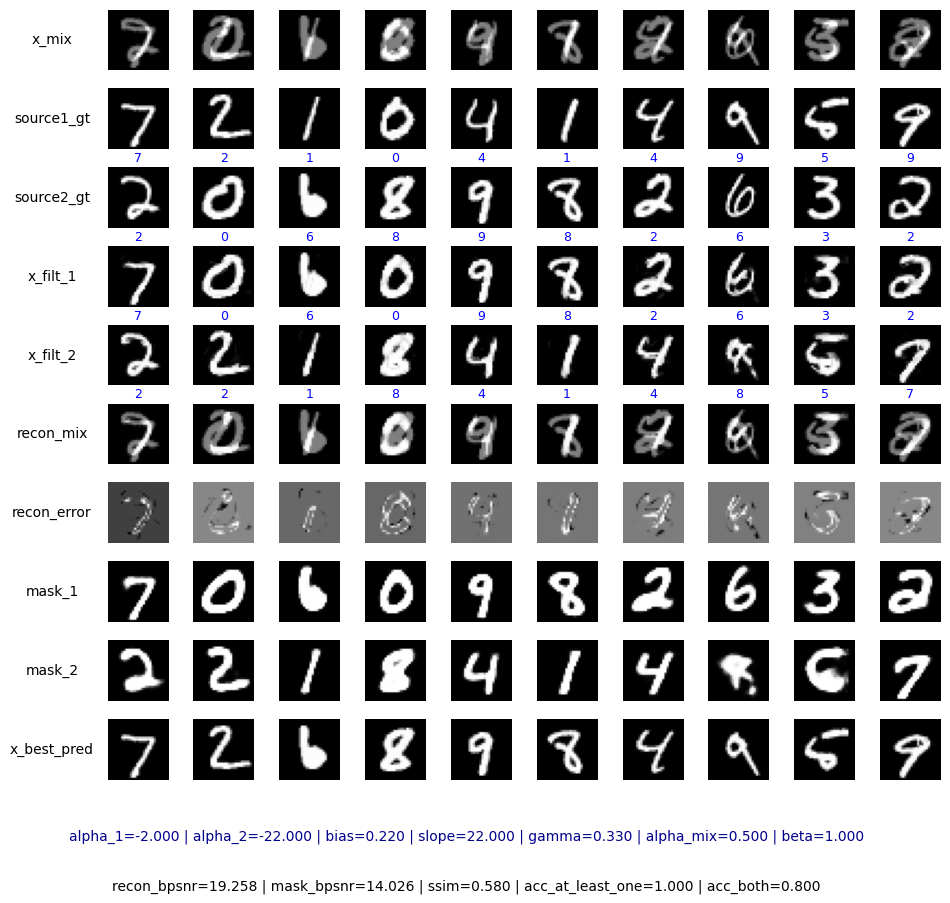


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -2.000
alpha_2   : -22.000
bias      : 0.220
slope     : 22.000
gamma     : 0.330
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.258  std:2.699
mask_bpsnr       : mean: 14.026  std:1.913
ssim             : mean: 0.580  std:0.107
acc_at_least_one : 1.000
acc_both         : 0.800



In [9]:
#codigo de una separación

import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader
from project.CROP.models.crop2 import Crop2 

SEED = 1234
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


ITERATIONS = 10
N_PICTURES = 10

DATASET = "mnist"
lat=64
inter=256
cvae = Loader.cvae(inter=inter,lat=lat,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]

c = Crop2(cvae=cvae,predictor=predictor)

#acc_both_params={'bias': 0.21716868437244724, 'slope': 19.437646607877017, 'alpha_1': -0.13863158439804657, 'alpha_2': -10.463749682840565, 'gamma': 0.5392507616026618}


metrics = c.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=True,
    labels=labels,
)




## Optimización de parametros

In [10]:
#optim + sepración
import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

SEED = 1234

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from project.loader import Loader
from project.CROP.models.crop2 import Crop2 

dataset = "mnist"

lat=64
inter=256
data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]


c = Crop2(predictor=predictor,lat=lat,inter=inter,dataset=dataset)

def objective(trial):

    #
    bias = trial.suggest_float("bias", 0.17,0.19)
    slope = trial.suggest_float("slope", 11,14 )
    gamma = trial.suggest_float("gamma", 0.25, 0.37)

    n_images=2000
    try:        
        metrics = c.unmix(
            x_test[:n_images],
            x_test_1[:n_images],
            y_test[:n_images],
            y_test_1[:n_images],
            params={"gamma": gamma,"bias":bias,"slope":slope},
            iterations=10,
            show_metrics=False
        )
        met = float(metrics["acc_both"])
        return  met

    except Exception as e:
        print(f"Error con bias={bias}, slope={slope}: {e}")
        return float("inf")
    

import optuna


study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials=20) 

# Mostramos los mejores resultados
print("\n📊 Mejores hiperparámetros encontrados:")
print(study.best_trials)



Usando mnist como dataset


[I 2026-02-04 12:55:45,517] A new study created in memory with name: no-name-62a44fc2-0f57-4670-80c0-318b6e1c993f
[I 2026-02-04 12:55:48,340] Trial 0 finished with value: 0.8245 and parameters: {'bias': 0.18498938944538887, 'slope': 13.523027958766482, 'gamma': 0.34687813346180363}. Best is trial 0 with value: 0.8245.
[I 2026-02-04 12:55:51,112] Trial 1 finished with value: 0.8245 and parameters: {'bias': 0.1780669789279213, 'slope': 11.367558648961028, 'gamma': 0.35027350905135635}. Best is trial 0 with value: 0.8245.
[I 2026-02-04 12:55:54,013] Trial 2 finished with value: 0.822 and parameters: {'bias': 0.17496773713221317, 'slope': 13.64405815480773, 'gamma': 0.2645094480000402}. Best is trial 0 with value: 0.8245.
[I 2026-02-04 12:55:56,706] Trial 3 finished with value: 0.823 and parameters: {'bias': 0.1827960578580136, 'slope': 13.500104285822301, 'gamma': 0.34513929004960153}. Best is trial 0 with value: 0.8245.
[I 2026-02-04 12:55:59,342] Trial 4 finished with value: 0.8255 and 


📊 Mejores hiperparámetros encontrados:
[FrozenTrial(number=15, state=1, values=[0.8315], datetime_start=datetime.datetime(2026, 2, 4, 12, 56, 27, 825624), datetime_complete=datetime.datetime(2026, 2, 4, 12, 56, 30, 501232), params={'bias': 0.18672837579779952, 'slope': 12.716609421660875, 'gamma': 0.2799402430972949}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'bias': FloatDistribution(high=0.19, log=False, low=0.17, step=None), 'slope': FloatDistribution(high=14.0, log=False, low=11.0, step=None), 'gamma': FloatDistribution(high=0.37, log=False, low=0.25, step=None)}, trial_id=15, value=None)]
